<a href="https://colab.research.google.com/github/lcorn132/TH_DeepLearning/blob/main/Tuan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Regression


###1.GIỚI THIỆU
Tương tự như mạng nơ-ron cho bài toán phân lớp, một mạng Artificial Neural Network (ANN) cấu hình cho bài toán Hồi quy (Regression) cũng bao gồm 4 đối tượng nền tảng:

Layers: Nơi diễn ra toàn bộ quá trình tính toán và học tập (gồm tầng Input, các tầng Hidden và tầng Output).

Feature và Label: Dữ liệu đầu vào mạng (feature) và giá trị mục tiêu cần dự báo (label). Đối với hồi quy, label là một giá trị số liên tục (ví dụ: giá nhà, nhiệt độ, thu nhập) chứ không phải nhãn lớp rời rạc.

Loss function: Hàm đo lường mức độ sai số giữa giá trị số do mạng đoán và giá trị thực tế.

Optimizer: Thuật toán cập nhật trọng số (weights) và độ lệch (bias) để tối ưu hóa mạng.

###2. KIẾN TRÚC NEURAL NETWORK CHO REGRESSION

####2.1. Cấu trúc tầng và Nơ-ron (Layers & Neurons)

Mạng hồi quy sử dụng các tầng kết nối đầy đủ (Fully Connected / Dense layers) để xử lý dữ liệu. Điểm khác biệt cốt lõi nằm ở Tầng đầu ra (Output Layer):

Số lượng Unit (Units): Luôn bằng 1 (hoặc bằng số lượng biến số liên tục cần dự báo đồng thời), thay vì bằng 10 như bài toán phân loại ảnh Fashion-MNIST.

Hàm kích hoạt (Activation Function): Ở tầng đầu ra, mạng hồi quy thường không dùng hàm activation (để mặc định hoặc dùng hàm tuyến tính linear). Điều này cho phép nơ-ron đầu ra tự do tính toán ra bất kỳ giá trị số thực nào (âm hoặc dương), thay vì ép về khoảng xác suất từ 0 đến 1 của hàm softmax.

In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.regularizers import l2

# 1. Khởi tạo mô hình chuỗi tuần tự cho bài toán Hồi quy
regression_model = Sequential()

# 2. Thêm tầng ẩn thứ nhất (có tích hợp L2 Regularization chống overfit)
regression_model.add(Dense(input_dim=X_train.shape[1], units=128,
                           kernel_regularizer=l2(0.01), activation='relu'))
regression_model.add(Dropout(0.2)) # Tỷ lệ dropout rate là 20%

# 3. Thêm tầng ẩn thứ hai
regression_model.add(Dense(units=64, activation='relu'))

# 4. TẦNG ĐẦU RA (OUTPUT LAYER FOR REGRESSION)
# Chỉ có 1 unit và sử dụng activation là 'linear' (hoặc bỏ trống) để dự báo số thực tự do
regression_model.add(Dense(units=1, activation='linear'))

# 5. Biên dịch mạng với Loss là 'mse' hoặc 'mae' thay vì crossentropy
regression_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

# 6. Xem cấu trúc mạng
regression_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 0 (0.00 B)

##Artificial Neural Network

In [ ]:
#install required libraries
!pip install scikeras
import pandas as pd
import numpy as np
#data visualization packages
import matplotlib.pyplot as plt
#keras packages
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Dropout
from scikeras.wrappers import KerasClassifier
#model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

In [ ]:
fashion = tf.keras.datasets.fashion_mnist
(X_train,y_train),(X_test,y_test) = fashion.load_data()
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [ ]:
X_train = X_train.reshape(60000,784)
X_test = X_test.reshape(10000,784)

minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


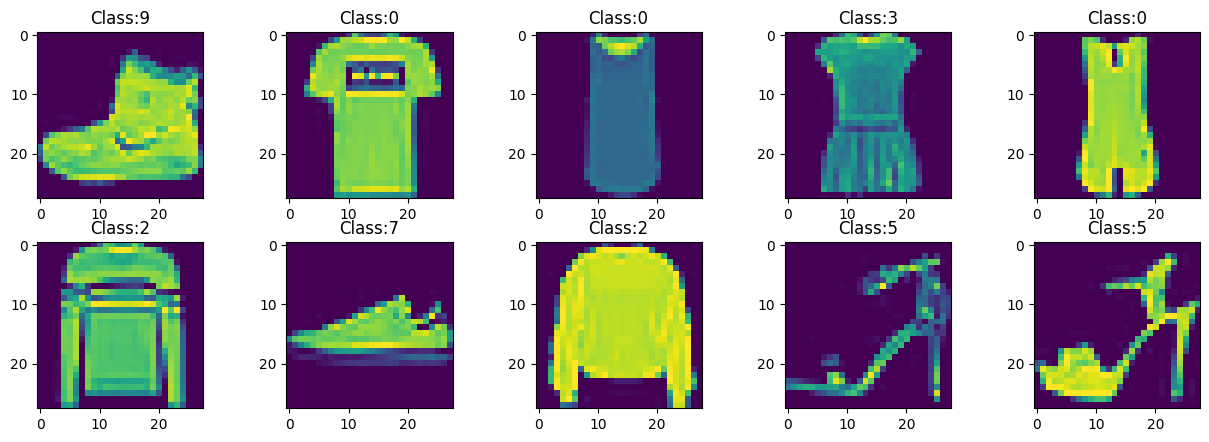

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(wspace=0.5)
plt.show()

In [ ]:
fashion_model = Sequential()

fashion_model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

fashion_model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

fashion_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_fit = fashion_model.fit(X_train, y_train, epochs=20, verbose=1, validation_split=0.1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8208 - loss: 0.5079 - val_accuracy: 0.8555 - val_loss: 0.3985
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8646 - loss: 0.3731 - val_accuracy: 0.8677 - val_loss: 0.3741
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8788 - loss: 0.3308 - val_accuracy: 0.8763 - val_loss: 0.3414
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8880 - loss: 0.3062 - val_accuracy: 0.8863 - val_loss: 0.3309
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8937 - loss: 0.2865 - val_accuracy: 0.8877 - val_loss: 0.3172
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8975 - loss: 0.2748 - val_accuracy: 0.8800 - val_loss: 0.3301
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9007 - loss: 0.2631 - val_accuracy: 0.8827 - val_loss: 0.3248
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9073 - loss: 0.2494 

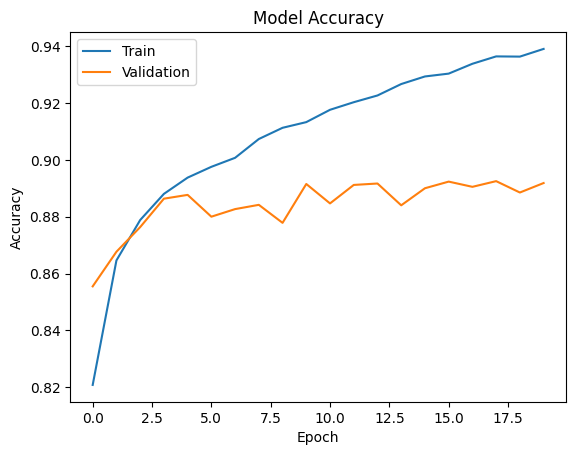

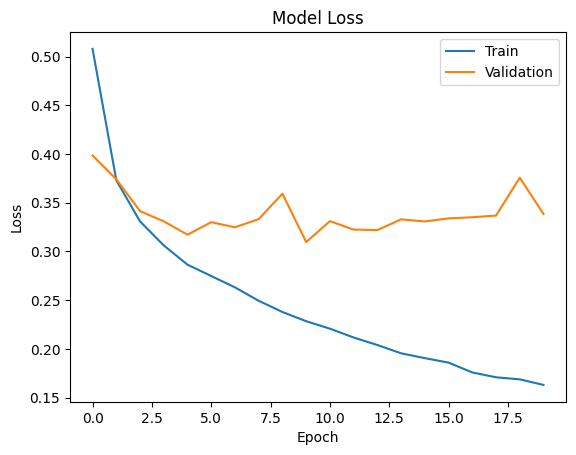

In [ ]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [ ]:
print('Predicted:', np.argmax(fashion_model.predict(X_test)[0]), 'Actual:', y_test[0])
print('Predicted:', np.argmax(fashion_model.predict(X_test)[10]), 'Actual:', y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted: 9 Actual: 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted: 4 Actual: 4


In [ ]:
import os

# 1. Tạo thư mục sample_data nếu chưa có
os.makedirs('/content/sample_data', exist_ok=True)

# 2. Tải dữ liệu Fashion MNIST gốc từ Keras
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# 3. Ép phẳng ảnh từ 2D (28x28) thành 1D (784 pixel) để chuyển sang cấu trúc bảng CSV
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 4. Đưa vào DataFrame và chèn cột 'label' vào đầu tiên
train_df = pd.DataFrame(X_train_flat)
train_df.insert(0, 'label', y_train)

test_df = pd.DataFrame(X_test_flat)
test_df.insert(0, 'label', y_test)

# 5. Xuất ra file CSV lưu vào thư mục mẫu của Colab
train_df.to_csv('/content/sample_data/fashion-mnist_train.csv', index=False)
test_df.to_csv('/content/sample_data/fashion-mnist_test.csv', index=False)

print("--- THÀNH CÔNG! ---")
print("Đã tạo xong file: /content/sample_data/fashion-mnist_train.csv")
print("Đã tạo xong file: /content/sample_data/fashion-mnist_test.csv")

--- THÀNH CÔNG! ---
Đã tạo xong file: /content/sample_data/fashion-mnist_train.csv
Đã tạo xong file: /content/sample_data/fashion-mnist_test.csv


In [ ]:
# Định nghĩa đường dẫn file
mnist_train_path = '/content/sample_data/fashion-mnist_train.csv'
mnist_test_path = '/content/sample_data/fashion-mnist_test.csv'

# Đọc tập dữ liệu
mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)

# In kiểm tra cấu trúc dữ liệu
print("5 dòng đầu của tập train:")
print(mnist_train.head())
print("Kích thước tập train:", mnist_train.shape)

5 dòng đầu của tập train:
   label  0  1  2  3  4  5  6  7   8  ...  774  775  776  777  778  779  780  \
0      9  0  0  0  0  0  0  0  0   0  ...    0    0    0    0    0    0    0   
1      0  0  0  0  0  0  1  0  0   0  ...  119  114  130   76    0    0    0   
2      0  0  0  0  0  0  0  0  0   0  ...    0    0    1    0    0    0    0   
3      3  0  0  0  0  0  0  0  0  33  ...    0    0    0    0    0    0    0   
4      0  0  0  0  0  0  0  0  0   0  ...    0    0    0    0    0    0    0   

   781  782  783  
0    0    0    0  
1    0    0    0  
2    0    0    0  
3    0    0    0  
4    0    0    0  

[5 rows x 785 columns]
Kích thước tập train: (60000, 785)


In [ ]:
# Tách các cột pixel (từ cột index 1 đến hết)
X_train = mnist_train.iloc[:, 1:]
X_test = mnist_test.iloc[:, 1:]
print("Kích thước X_train:", X_train.shape)

# Tách cột nhãn (cột index 0) [cite: 413, 414]
y_train = mnist_train.iloc[:, 0]
y_test = mnist_test.iloc[:, 0]

# Kiểm tra các lớp phân loại [cite: 415, 416]
print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Kích thước X_train: (60000, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
# Khởi tạo chuỗi mạng nơ-ron
model = Sequential()

# Thêm lớp ẩn gồm 256 nơ-ron
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Thêm lớp đầu ra gồm 10 nơ-ron
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Biên dịch mô hình
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Hiển thị cấu trúc mạng
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Thực hiện huấn luyện mô hình trong 30 vòng lặp
model_fit = model.fit(X_train, y_train, epochs=30, verbose=1)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7920 - loss: 1.0545
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8278 - loss: 0.4953
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8346 - loss: 0.4841
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8371 - loss: 0.4788
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8411 - loss: 0.4631
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8444 - loss: 0.4570
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8457 - loss: 0.4552
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8480 - loss: 0.4494
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8515 - loss: 0.4385
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8484 - loss: 0.4473
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8518 - loss: 0.4333
Epoch 12/30
1875/1875 ━

In [ ]:
# Dự đoán nhãn cho tập dữ liệu test
predictions = model.predict(X_test)

# Lấy ra lớp có xác suất cao nhất của phần tử đầu tiên và so sánh với nhãn thật
print("Nhãn mô hình dự đoán:", np.argmax(predictions[0]))
print("Nhãn thực tế (đáp án đúng):", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Nhãn mô hình dự đoán: 9
Nhãn thực tế (đáp án đúng): 9


In [ ]:
img_size = (28, 28)
img = tf.keras.preprocessing.image.load_img(
    '/content/sample_data/dress_1.jpg', color_mode='grayscale', target_size=img_size)
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array, (784))
img_array = tf.expand_dims(img, 0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)
img_predict = model.predict(img_array)
print(img_predict)
score = np.argmax(img_predict)
print(score)

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[1.5466921e-16 6.0167204e-26 3.9477454e-25 3.2571736e-20 1.6265385e-22
  9.8331427e-08 2.4125735e-10 8.4373030e-13 9.9999988e-01 3.6289326e-11]]
8


##Bài tập

###1. Viết chương trình cài đặt ANN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow với 10 nhãn (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)


In [ ]:
# 1. Tải bộ dữ liệu CIFAR10 từ hệ thống tensorflow
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# 2. Chuẩn hóa dữ liệu pixel từ khoảng [0, 255] về khoảng [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# 3. Xây dựng cấu trúc mạng ANN tuần tự (Sequential)
# Sử dụng Flatten để ép phẳng ma trận ảnh màu 3D (32x32x3) thành mảng 1D (3072 phần tử)
model_cifar = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation='relu'),      # Lớp ẩn thứ nhất với 512 nơ-ron
    Dense(256, activation='relu'),      # Lớp ẩn thứ hai với 256 nơ-ron
    Dense(10, activation='softmax')     # Lớp đầu ra tương ứng với 10 lớp phân loại
])

# 4. Biên dịch mô hình (Cấu hình bộ tối ưu và hàm mất mát)
model_cifar.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# 5. Huấn luyện mô hình (Chạy trong 15 vòng lặp)
print("--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH CIFAR10 ---")
model_cifar.fit(X_train, y_train, epochs=15, batch_size=64, validation_split=0.1)

# Đánh giá nhanh độ chính xác trên tập kiểm thử mẫu
test_loss, test_acc = model_cifar.evaluate(X_test, y_test, verbose=0)
print(f"\nHuấn luyện hoàn tất! Độ chính xác trên tập Test đạt: {test_acc*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH CIFAR10 ---
Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.3245 - loss: 1.8755 - val_accuracy: 0.3610 - val_loss: 1.7934
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - accuracy: 0.3982 - loss: 1.6834 - val_accuracy: 0.4172 - val_loss: 1.6602
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.4256 - loss: 1.5972 - val_accuracy: 0.4426 - val_loss: 1.5718
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.4549 - loss: 1.5308 - val_accuracy: 0.4492 - val_loss: 1.5548
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.4683 - loss: 1.4932 - val_accuracy: 0.4644 - val_loss: 1.5293
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.4792 - loss: 1.4579 - val_accuracy: 0.4584 - val_loss: 1.5263
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.4933 - loss: 1.4297 - val_accuracy: 0.4808 - val_loss: 1.4741
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26m